### Using Tensorflow

In [ ]:
import pandas as pd
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout 

c:\Users\BAPS\AppData\Local\Programs\Python\Python311\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/attr_value.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
c:\Users\BAPS\AppData\Local\Programs\Python\Python311\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/tensor.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
c:\Users\BAPS\AppData\Local\Programs\Python\Python311\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/

### Using PyTorch

In [82]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

In [83]:
os.getcwd()
os.chdir(r"c:\\Users\\BAPS\\Desktop\\Python")
os.getcwd()

'c:\\Users\\BAPS\\Desktop\\Python'

In [84]:
import torch
import torch.nn as nn
from torch.autograd import Variable
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader,TensorDataset

In [85]:
train=pd.read_csv(r"Datasets\digit_recognizer_dataset\train.csv")
train.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [86]:
target=train.label.values
features=train.loc[:,train.columns !="label"].values/255
features_train,features_test,target_train,target_test=train_test_split(features,target,test_size=0.2,random_state=18)

In [87]:
featuresTrain = torch.from_numpy(features_train).float()
targetTrain = torch.from_numpy(target_train).type(torch.LongTensor)

In [88]:
featuresTest = torch.from_numpy(features_test).float()
targetTest = torch.from_numpy(target_test).type(torch.LongTensor)

In [89]:
batch_size=100
n_ters=15000
num_epochs=n_ters/(len(features_train)/batch_size)
num_epochs=int(num_epochs)
print(num_epochs)

44


In [90]:
train=TensorDataset(featuresTrain,targetTrain)
test=TensorDataset(featuresTest,targetTest)

In [91]:
train_loader = DataLoader(train, batch_size=batch_size,shuffle=False)
test_loader = DataLoader(test,batch_size=batch_size,shuffle=False)

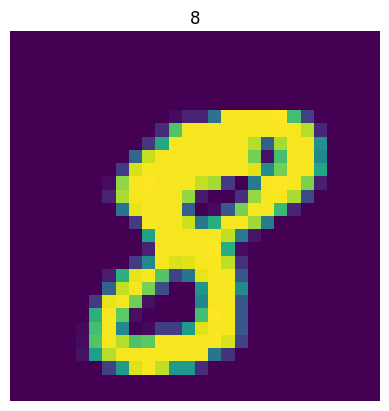

In [92]:
plt.imshow(features[10].reshape(28,28))
plt.axis("off")
plt.title(str(target[10]))
plt.show()

In [93]:
print("Training ->",len(train_loader.dataset))
print("Testing ->",len(test_loader.dataset))

Training -> 33600
Testing -> 8400


In [94]:
class LSTM(nn.Module):
    def __init__(self,input_dim,hidden_dim,layer_dim,output):
        super(LSTM,self).__init__()

        self.input_dim=input_dim
        self.hidden_dim=hidden_dim
        self.layer=layer_dim
        self.output_dim=output

        self.lstm = nn.LSTM(input_dim,hidden_dim,layer_dim,batch_first=True)
        self.fc = nn.Linear(hidden_dim,output)

    def forward(self,x):
        h0=torch.zeros(self.layer,x.size(0),self.hidden_dim).requires_grad_()

        c0=torch.zeros(self.layer,x.size(0),self.hidden_dim).requires_grad_()

        out,(hn,cn) = self.lstm(x,(h0.detach(),c0.detach()))

        out= self.fc(out[:,-1,:])   

        return out
    
input=28
hidden=100
layers=1
output=10

model = LSTM(input,hidden,layers,output)

print(model)

LSTM(
  (lstm): LSTM(28, 100, batch_first=True)
  (fc): Linear(in_features=100, out_features=10, bias=True)
)


In [95]:
error = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(),lr=0.1)

In [101]:
sequence =28
losses=[]
iter = []
accuracy =[]
count=0
 
for epoch in range(num_epochs):
    for i,(img,label) in enumerate(train_loader):
        img= img.view(-1,sequence,input).requires_grad_()

        optimizer.zero_grad()
        outputs=model(img)
        loss=error(outputs,label)

        loss.backward()
        optimizer.step()

        count+=1

        if count%500==0:
            correct=0
            total=0

            for img,label in test_loader:
                img=img.view(-1,sequence,input)

                outputs= model(img)
                _,predicted = torch.max(outputs.data,1)
    
                total+=label.size(0)
                correct +=(predicted==label).sum()

            acc= 100 * correct / total

            losses.append(loss.data.item())
            iter.append(count)
            accuracy.append(acc)

            print(f"Epoch:{epoch}\nIneration:{count},\tLoss:{loss.data.item()},\tAccuracy:{acc}")

Epoch:1
Ineration:500,	Loss:0.11639847606420517,	Accuracy:98.0952377319336
Epoch:2
Ineration:1000,	Loss:0.08857540786266327,	Accuracy:98.13095092773438
Epoch:4
Ineration:1500,	Loss:0.008500833064317703,	Accuracy:97.94047546386719
Epoch:5
Ineration:2000,	Loss:0.004064264707267284,	Accuracy:98.19047546386719
Epoch:7
Ineration:2500,	Loss:0.008673455566167831,	Accuracy:97.79762268066406
Epoch:8
Ineration:3000,	Loss:0.002133803442120552,	Accuracy:98.27381134033203
Epoch:10
Ineration:3500,	Loss:0.012962615117430687,	Accuracy:97.98809814453125
Epoch:11
Ineration:4000,	Loss:0.00486103305593133,	Accuracy:98.17857360839844
Epoch:13
Ineration:4500,	Loss:0.0020678031723946333,	Accuracy:98.21428680419922
Epoch:14
Ineration:5000,	Loss:0.0054146177135407925,	Accuracy:98.20237731933594
Epoch:16
Ineration:5500,	Loss:0.0014331695856526494,	Accuracy:98.16666412353516
Epoch:17
Ineration:6000,	Loss:0.01947159878909588,	Accuracy:98.0952377319336
Epoch:19
Ineration:6500,	Loss:0.009254167787730694,	Accuracy:9

In [102]:
import cv2

# load and preprocess image
img = cv2.imread(r"Images\number5.jpg", cv2.IMREAD_GRAYSCALE)
img = cv2.resize(img, (28, 28))
img = img / 255.0
img = torch.tensor(img).float().view(1, 28, 28)

model.eval()
with torch.no_grad():
    output = model(img)
    _, predicted = torch.max(output, 1)

print("Predicted digit:", predicted.item())

Predicted digit: 5
